# ADA Semester Project

This represents the project for the CS-401 course at EPFL, done by:

| SCIPER                                              | Name                      |
|:----------------------------------------------------|:--------------------------|
| [356420](https://people.epfl.ch/badr.almahouri)     | Badr Al Mahouri           |
| [341237](https://people.epfl.ch/louis.grange)       | Louis Grange              |
| [340497](https://people.epfl.ch/daniel.alvesataide) | Daniel Ataíde             |
| [329310](https://people.epfl.ch/arnaud.tadic)       | Arnaud Jacques Yves Tadic |
| [308396](https://people.epfl.ch/yuri.cho)           | Yuri Cho                  |

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xlrd import count_records

import src.data as utils


# Import dataset
We're using the reddit hyperlinks dataset. It's separated into 2 files: one for hyperlinks in the body of posts and the other for hyperlinks in the title of posts.
In addition, we have the embeddings dataset for subereddits and users. They represent each user or subreddit as a 300-dimensional vector, which we can use to compute similarities between them.

In [4]:
body_data, title_data, subreddits_data, users_data, events_data = utils.load_data()

100%|██████████| 297M/297M [00:20<00:00, 15.5MB/s] 

Extracting files...


Loading datasets from /Users/ycho/.cache/kagglehub/datasets/fejwiehf3928uhcwa/ada-2025-project-bald/versions/2
Completed


In [5]:
body_data

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES
0,leagueoflegends,teamredditteams,1u4nrps,2013-12-31 16:39:58,1,"345.0,298.0,0.75652173913,0.0173913043478,0.08..."
1,theredlion,soccer,1u4qkd,2013-12-31 18:18:37,-1,"101.0,98.0,0.742574257426,0.019801980198,0.049..."
2,inlandempire,bikela,1u4qlzs,2014-01-01 14:54:35,1,"85.0,85.0,0.752941176471,0.0235294117647,0.082..."
3,nfl,cfb,1u4sjvs,2013-12-31 17:37:55,1,"1124.0,949.0,0.772241992883,0.0017793594306,0...."
4,playmygame,gamedev,1u4w5ss,2014-01-01 02:51:13,1,"715.0,622.0,0.777622377622,0.00699300699301,0...."
...,...,...,...,...,...,...
286556,negareddit,debatefascism,68im20s,2017-04-30 16:31:26,1,"441.0,405.0,0.775510204082,0.0294784580499,0.0..."
286557,mildlynomil,justnomil,68imlas,2017-04-30 04:19:03,1,"2226.0,1855.0,0.786163522013,0.00224618149146,..."
286558,mmorpg,blackdesertonline,68ip5os,2017-04-30 16:54:08,1,"1100.0,909.0,0.778181818182,0.00181818181818,0..."
286559,electricskateboards,askreddit,68ipb2s,2017-04-30 16:41:53,1,"1876.0,1567.0,0.78144989339,0.00692963752665,0..."


In [6]:
title_data

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES
0,rddtgaming,rddtrust,1u4pzzs,2013-12-31 16:39:18,1,"25.0,23.0,0.76,0.0,0.44,0.12,0.12,4.0,4.0,0.0,..."
1,xboxone,battlefield_4,1u4tmfs,2013-12-31 17:59:11,1,"100.0,88.0,0.78,0.02,0.08,0.13,0.07,16.0,16.0,..."
2,ps4,battlefield_4,1u4tmos,2013-12-31 17:59:40,1,"100.0,88.0,0.78,0.02,0.08,0.13,0.07,16.0,16.0,..."
3,fitnesscirclejerk,leangains,1u50xfs,2013-12-31 19:01:56,1,"49.0,43.0,0.775510204082,0.0,0.265306122449,0...."
4,fitnesscirclejerk,lifeprotips,1u51nps,2013-12-31 21:02:28,1,"14.0,14.0,0.785714285714,0.0,0.428571428571,0...."
...,...,...,...,...,...,...
571922,seattleshitshow,seattlewa,68iptp,2017-04-27 11:07:31,-1,"83.0,70.0,0.78313253012,0.0,0.10843373494,0.16..."
571923,peoplewhosayheck,spiderman,68iqh6s,2017-04-30 16:36:07,1,"121.0,105.0,0.719008264463,0.0165289256198,0.0..."
571924,vzla,wtf,68iqkcs,2017-04-30 15:50:07,1,"68.0,58.0,0.764705882353,0.0,0.147058823529,0...."
571925,denverbroncos,nfl,68iqt8,2017-04-30 16:11:30,-1,"96.0,79.0,0.770833333333,0.0,0.0729166666667,0..."


In [7]:
subreddits_data

,SUBREDDIT,EMBEDDING_0,EMBEDDING_1,EMBEDDING_2,EMBEDDING_3,EMBEDDING_4,EMBEDDING_5,EMBEDDING_6,EMBEDDING_7,EMBEDDING_8,...,EMBEDDING_290,EMBEDDING_291,EMBEDDING_292,EMBEDDING_293,EMBEDDING_294,EMBEDDING_295,EMBEDDING_296,EMBEDDING_297,EMBEDDING_298,EMBEDDING_299
0,spiders,0.158972,0.285813,0.226329,-0.183338,-0.163159,-0.188910,0.422705,0.168602,0.178193,...,-0.025041,0.184655,0.111942,-1.125799,0.223129,-0.387323,-0.234882,-0.252297,-0.054315,0.500009
1,askreddit,-0.499114,0.323983,-0.424809,-0.222705,-0.327201,0.412856,1.040088,0.996697,-1.256240,...,0.072151,0.226658,0.535705,0.039861,-0.027087,-0.239952,0.554510,0.676439,-0.328846,0.941547
2,globaloffensivetrade,-0.023145,-1.199374,1.661484,-1.025296,1.424670,-1.179507,-1.035703,0.329301,-0.567272,...,2.998430,-1.235703,-0.326850,4.381238,-1.965378,-2.369674,-0.615389,2.010601,-0.919314,-2.149625
3,fireteams,2.492506,-2.529917,-0.448484,-3.543441,-0.586122,-0.101517,1.837567,-0.215715,-2.460388,...,-1.875214,0.969291,0.497958,2.941132,2.423561,1.315691,-0.959618,0.151845,-0.852492,-0.467526
4,funny,-0.819370,-0.865261,0.301753,0.018787,0.201029,0.070462,0.903895,1.038460,-0.306950,...,1.364194,0.830233,-0.137822,-2.204667,-0.162008,0.390291,-0.556404,0.322684,0.641634,1.320716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51273,33rd,-0.000076,-0.001643,-0.002896,0.000581,-0.003509,-0.000827,0.002095,0.000123,0.004370,...,-0.001570,-0.002246,0.003491,-0.004310,0.001598,0.005168,-0.001156,0.001575,-0.001938,0.001594
51274,bestofvic2015,-0.000203,0.012698,-0.007575,0.006486,-0.001693,0.004743,-0.002401,0.000121,0.001600,...,0.001392,0.001258,0.002970,-0.014106,-0.002713,-0.008648,0.003660,-0.005755,-0.001790,-0.001313
51275,aberystwyth,-0.001563,0.004733,-0.000082,-0.000982,-0.001511,0.001285,0.002187,0.002967,0.000660,...,0.002213,0.000520,-0.000564,-0.010018,0.002507,-0.000651,0.004169,-0.004672,0.002371,0.001073
51276,mail_forwarding,0.009269,0.024779,-0.017018,-0.007228,0.002351,0.003462,-0.008446,0.004544,0.022505,...,-0.002591,0.003482,0.001042,-0.002796,0.010739,-0.009148,0.000363,-0.003144,0.001945,-0.017272


In [8]:
users_data

,USER,EMBEDDING_0,EMBEDDING_1,EMBEDDING_2,EMBEDDING_3,EMBEDDING_4,EMBEDDING_5,EMBEDDING_6,EMBEDDING_7,EMBEDDING_8,...,EMBEDDING_290,EMBEDDING_291,EMBEDDING_292,EMBEDDING_293,EMBEDDING_294,EMBEDDING_295,EMBEDDING_296,EMBEDDING_297,EMBEDDING_298,EMBEDDING_299
0,rotoreuters,-0.224305,0.034301,-0.082651,0.004676,0.006960,0.892179,-0.309423,0.570185,0.492110,...,-0.380348,-0.144160,-0.289317,0.471727,-0.174092,0.534364,0.218821,0.269216,-0.412621,-0.469088
1,fiplefip,-0.306765,0.259314,-0.950335,0.560013,-0.364981,0.073359,-0.256642,-0.348088,-0.030323,...,-0.432182,-0.769793,-0.434484,0.268733,-0.163076,-0.455654,0.416560,-0.219805,-0.568944,-0.477788
2,amici_ursi,-0.234556,0.609160,-0.065395,-0.212264,0.269761,-0.562834,-0.455435,-0.349673,0.391979,...,0.622636,0.234270,0.083597,-0.647548,0.103007,0.344196,0.140004,0.579194,-0.046483,-0.705478
3,unremovable,0.253033,0.548086,-0.538728,0.375164,-0.129068,0.307664,-0.047697,-0.492977,0.224615,...,0.165165,-0.216920,-0.414641,-0.144242,0.185060,0.356242,0.095848,0.403010,-0.320782,-0.735368
4,CDRE_64,-0.008056,0.050560,-0.295054,-0.046483,0.042420,0.345231,0.075705,-0.198281,0.139585,...,-0.221219,-0.474621,-0.149465,-0.156034,-0.115828,-0.170805,0.284541,-0.144770,-0.050010,-0.341634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118376,rajkumareco,-0.069814,0.023679,0.032822,-0.200074,0.064771,0.157998,0.053184,-0.124960,-0.068105,...,-0.030709,-0.097185,0.029929,-0.067463,-0.265459,-0.201405,0.254439,0.006016,0.013839,0.105910
118377,roryswife,-0.102751,-0.008857,-0.131908,-0.154319,-0.023083,0.022363,0.090508,-0.034480,-0.033439,...,-0.084732,-0.160888,-0.036171,-0.049265,-0.040469,-0.160486,0.059213,0.051630,0.093915,-0.017583
118378,shillagepeople,0.008636,0.067610,-0.133499,-0.057814,0.047882,0.027176,0.047853,-0.066698,-0.047510,...,-0.031517,-0.191591,-0.032287,0.034490,-0.041353,-0.125495,0.162754,0.004968,-0.006810,-0.037618
118379,trizock,0.101569,0.050567,-0.096631,-0.068904,-0.047230,0.123565,-0.131402,-0.131583,-0.143453,...,-0.076321,0.071303,-0.040878,0.047556,0.079397,-0.050565,0.107052,0.139607,-0.064489,-0.177276


# Methods (POC)
We wish to implement different methods to analyze the data. Here are some proof of concepts.

To preprocess the data, we wish to do the following:
- Apply KNN clustering to the subreddits embeddings dataset to find similar subreddits.
- Manually pick some clusters related to commerce.
- Filter the subreddits (low-activity, non-English, other)
- Provide a finished list of subreddits to be used in the analysis.

In [9]:
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity

# Counting how many appearances each subreddit has as 'SOURCE_SUBREDDIT'

count_source_body = body_data['SOURCE_SUBREDDIT'].value_counts().reset_index()
count_source_body.columns = ['SUBREDDIT', 'POST_COUNT_BODY']

count_source_title = title_data['SOURCE_SUBREDDIT'].value_counts().reset_index()
count_source_title.columns = ['SUBREDDIT', 'POST_COUNT_TITLE']

combined_source_counts = pd.merge(count_source_body, count_source_title, on='SUBREDDIT', how='outer').fillna(0)

combined_source_counts['POST_COUNT_SOURCE'] = combined_source_counts['POST_COUNT_BODY'] + combined_source_counts['POST_COUNT_TITLE']

source_count = pd.merge(subreddits_data[['SUBREDDIT']], combined_source_counts,
                            on='SUBREDDIT', how='left')

source_count.dropna(subset=['POST_COUNT_SOURCE'], inplace=True)
source_count[source_count['POST_COUNT_SOURCE'] > 100].sort_values(by='POST_COUNT_SOURCE', ascending=False)


,SUBREDDIT,POST_COUNT_BODY,POST_COUNT_TITLE,POST_COUNT_SOURCE
495,subredditdrama,4665.0,22971.0,27636.0
381,bestof,0.0,21170.0,21170.0
1633,titlegore,3.0,9500.0,9503.0
1289,shitredditsays,501.0,7338.0,7839.0
1431,drama,1306.0,5478.0,6784.0
...,...,...,...,...
20889,shitleftistssay,7.0,94.0,101.0
1219,climbing,30.0,71.0,101.0
3173,baconreader,80.0,21.0,101.0
29056,soviethistory,1.0,100.0,101.0


In [10]:
# Counting how many appearances each subreddit has 'TARGET_SUBREDDIT'
count_target_body = body_data['TARGET_SUBREDDIT'].value_counts().reset_index()
count_target_body.columns = ['SUBREDDIT', 'POST_COUNT_BODY']

count_target_title = title_data['TARGET_SUBREDDIT'].value_counts().reset_index()
count_target_title.columns = ['SUBREDDIT', 'POST_COUNT_TITLE']

combined_target_counts = pd.merge(count_target_body, count_target_title, on='SUBREDDIT', how='outer').fillna(0)

combined_target_counts['POST_COUNT_TARGET'] = combined_target_counts['POST_COUNT_BODY'] + combined_target_counts['POST_COUNT_TITLE']

target_count = pd.merge(subreddits_data[['SUBREDDIT']], combined_target_counts,
                            on='SUBREDDIT', how='left')

target_count.dropna(subset=['POST_COUNT_TARGET'], inplace=True)
target_count[target_count['POST_COUNT_TARGET'] > 100].sort_values(by='POST_COUNT_TARGET', ascending=False)


,SUBREDDIT,POST_COUNT_BODY,POST_COUNT_TITLE,POST_COUNT_TARGET
1,askreddit,7329.0,19293.0,26622.0
456,iama,3694.0,9752.0,13446.0
10,pics,2779.0,9799.0,12578.0
33,todayilearned,2371.0,8753.0,11124.0
4,funny,2046.0,8731.0,10777.0
...,...,...,...,...
9732,aislingduval,33.0,68.0,101.0
4229,connery,15.0,86.0,101.0
713,beyondthebump,36.0,65.0,101.0
2195,patientgamers,37.0,64.0,101.0


In [11]:
# Total appearances as SOURCE or TARGET
total_counts = pd.merge(source_count, target_count, on='SUBREDDIT', how='outer', suffixes=('_SOURCE', '_TARGET')).fillna(0)
total_counts['POST_COUNT_TOTAL'] = total_counts['POST_COUNT_SOURCE'] + total_counts['POST_COUNT_TARGET']
total_counts[total_counts['POST_COUNT_TOTAL'] > 100].sort_values(by='POST_COUNT_TOTAL', ascending=False)[['SUBREDDIT', 'POST_COUNT_TOTAL']]

# Finally filter subreddits_data to only include subreddits with more than 100 total posts
active_subreddits = subreddits_data[subreddits_data['SUBREDDIT'].isin(total_counts[total_counts['POST_COUNT_TOTAL'] > 100]['SUBREDDIT'])]
subreddits_name = active_subreddits['SUBREDDIT']
# export to csv
subreddits_name.to_csv('subreddits_names.csv', index=False)


K-MEANS CLUSTERING ANALYSIS
K= 5 | Silhouette: 0.105 | Davies-Bouldin: 2.484
K=10 | Silhouette: 0.108 | Davies-Bouldin: 2.583
K=15 | Silhouette: 0.099 | Davies-Bouldin: 2.329
K=20 | Silhouette: 0.101 | Davies-Bouldin: 2.227
K=25 | Silhouette: 0.112 | Davies-Bouldin: 2.171
K=30 | Silhouette: 0.067 | Davies-Bouldin: 2.025


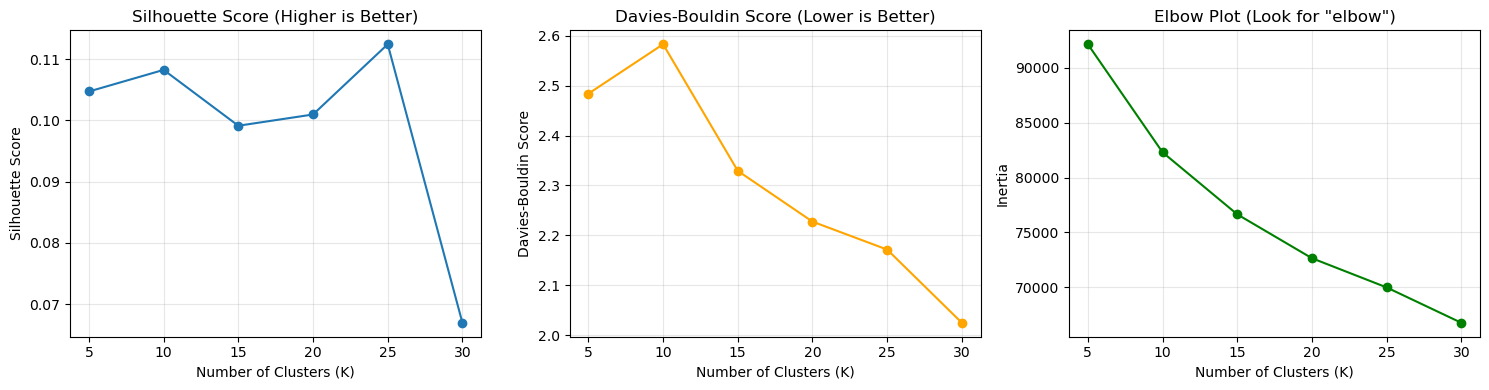

In [12]:
# Cluster subreddits using KNN
def perform_kmeans_analysis(embeddings, subreddit_names, k_range=range(5, 31, 5)):
    """
    Initial Analysis using different K values for K-means clustering.
    """
    results = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(embeddings)

        # Calculate metrics
        silhouette = silhouette_score(embeddings, cluster_labels)
        davies_bouldin = davies_bouldin_score(embeddings, cluster_labels)
        inertia = kmeans.inertia_

        results.append({
            'k': k,
            'silhouette_score': silhouette,
            'davies_bouldin_score': davies_bouldin,
            'inertia': inertia
        })

        print(f"K={k:2d} | Silhouette: {silhouette:.3f} | Davies-Bouldin: {davies_bouldin:.3f}")

    return pd.DataFrame(results)

# Run K-means analysis
print("\n" + "="*70)
print("K-MEANS CLUSTERING ANALYSIS")
print("="*70)
# Extract embeddings without subreddit names
embeddings = active_subreddits.drop(columns=['SUBREDDIT'])
kmeans_results = perform_kmeans_analysis(embeddings, active_subreddits['SUBREDDIT'])

# Plot clustering metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(kmeans_results['k'], kmeans_results['silhouette_score'], 'o-')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score (Higher is Better)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(kmeans_results['k'], kmeans_results['davies_bouldin_score'], 'o-', color='orange')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Davies-Bouldin Score (Lower is Better)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(kmeans_results['k'], kmeans_results['inertia'], 'o-', color='green')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('Inertia')
axes[2].set_title('Elbow Plot (Look for "elbow")')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()


PERFORMING K-MEANS WITH K=25

Reducing 300D embeddings to 2D using t-SNE...
This may take a few minutes...


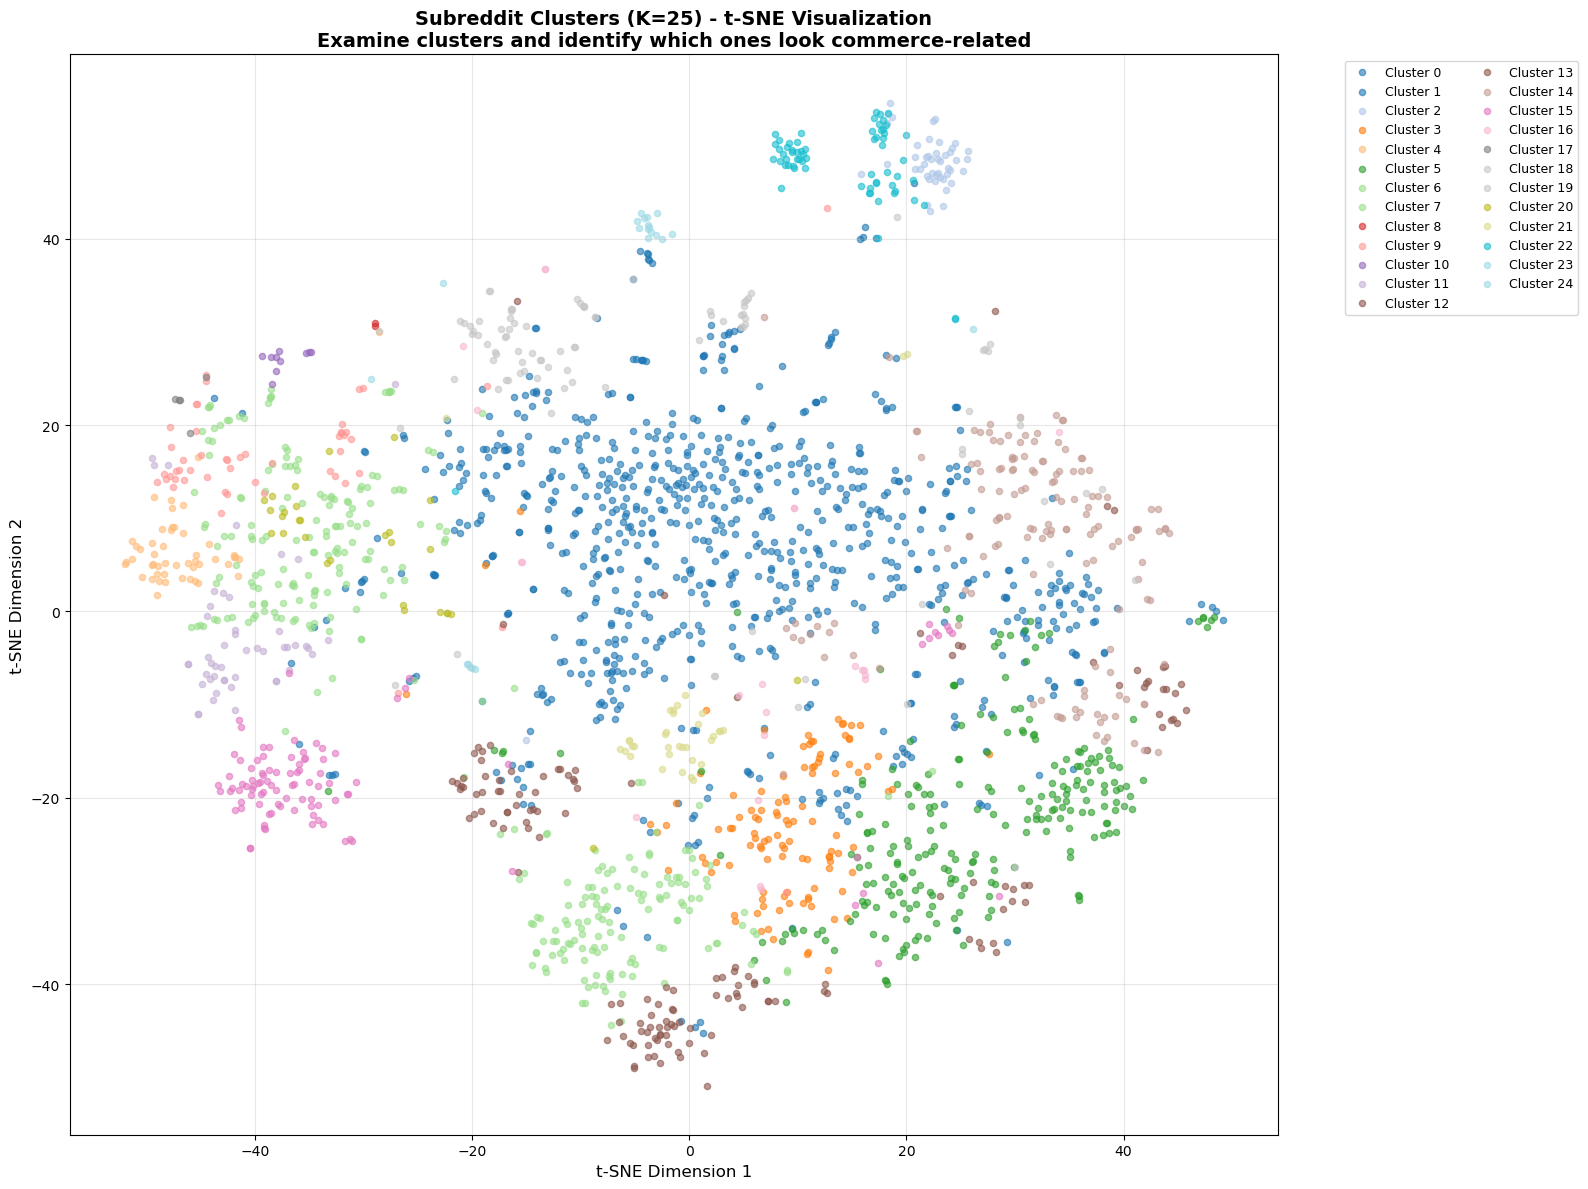

In [13]:
# Based on the plots above, choose your optimal K
optimal_k = 25  # Adjust this based on the metrics above

print(f"\n" + "="*70)
print(f"PERFORMING K-MEANS WITH K={optimal_k}")
print("="*70)

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

# Create a DataFrame with subreddit-cluster mapping
cluster_df = pd.DataFrame({
    'subreddit': active_subreddits['SUBREDDIT'],
    'cluster': cluster_labels
})

def visualize_clusters_2d(embeddings, subreddit_names, cluster_labels, n_clusters):
    """
    Reduce embeddings to 2D with t-SNE and visualize clusters.
    """
    print(f"\nReducing {embeddings.shape[1]}D embeddings to 2D using t-SNE...")
    print("This may take a few minutes...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d = tsne.fit_transform(embeddings)

    # Create DataFrame for easier plotting
    viz_df = pd.DataFrame({
        'subreddit': subreddit_names,
        'x': embeddings_2d[:, 0],
        'y': embeddings_2d[:, 1],
        'cluster': cluster_labels
    })

    # Plot
    plt.figure(figsize=(16, 12))

    # Create a color map
    colors = plt.cm.tab20(np.linspace(0, 1, n_clusters))

    # Plot each cluster
    for cluster_id in range(n_clusters):
        cluster_data = viz_df[viz_df['cluster'] == cluster_id]
        plt.scatter(cluster_data['x'], cluster_data['y'],
                   c=[colors[cluster_id]],
                   label=f'Cluster {cluster_id}',
                   alpha=0.6,
                   s=20)

    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.title(f'Subreddit Clusters (K={n_clusters}) - t-SNE Visualization\n' +
              'Examine clusters and identify which ones look commerce-related',
              fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('subreddit_clusters_tsne.png', dpi=300, bbox_inches='tight')
    plt.show()

    return viz_df

viz_df = visualize_clusters_2d(embeddings, active_subreddits['SUBREDDIT'], cluster_labels, optimal_k)

In [12]:
viz_df[viz_df['cluster'] == 24]
# 8 pas mal

,subreddit,x,y,cluster
48,fifa,-2.983923,42.774540,24
50,soccer,-4.425828,42.807053,24
114,sneakers,-19.758507,-6.166971,24
121,streetwear,-20.008827,-6.030587,24
219,supremeclothing,-20.224207,-5.908165,24
272,fashionreps,-20.425329,-5.684023,24
341,repsneakers,-20.469475,-5.624275,24
347,reddevils,-3.900065,42.383572,24
395,gunners,-4.161816,42.262638,24
449,cricket,26.145893,30.336695,24


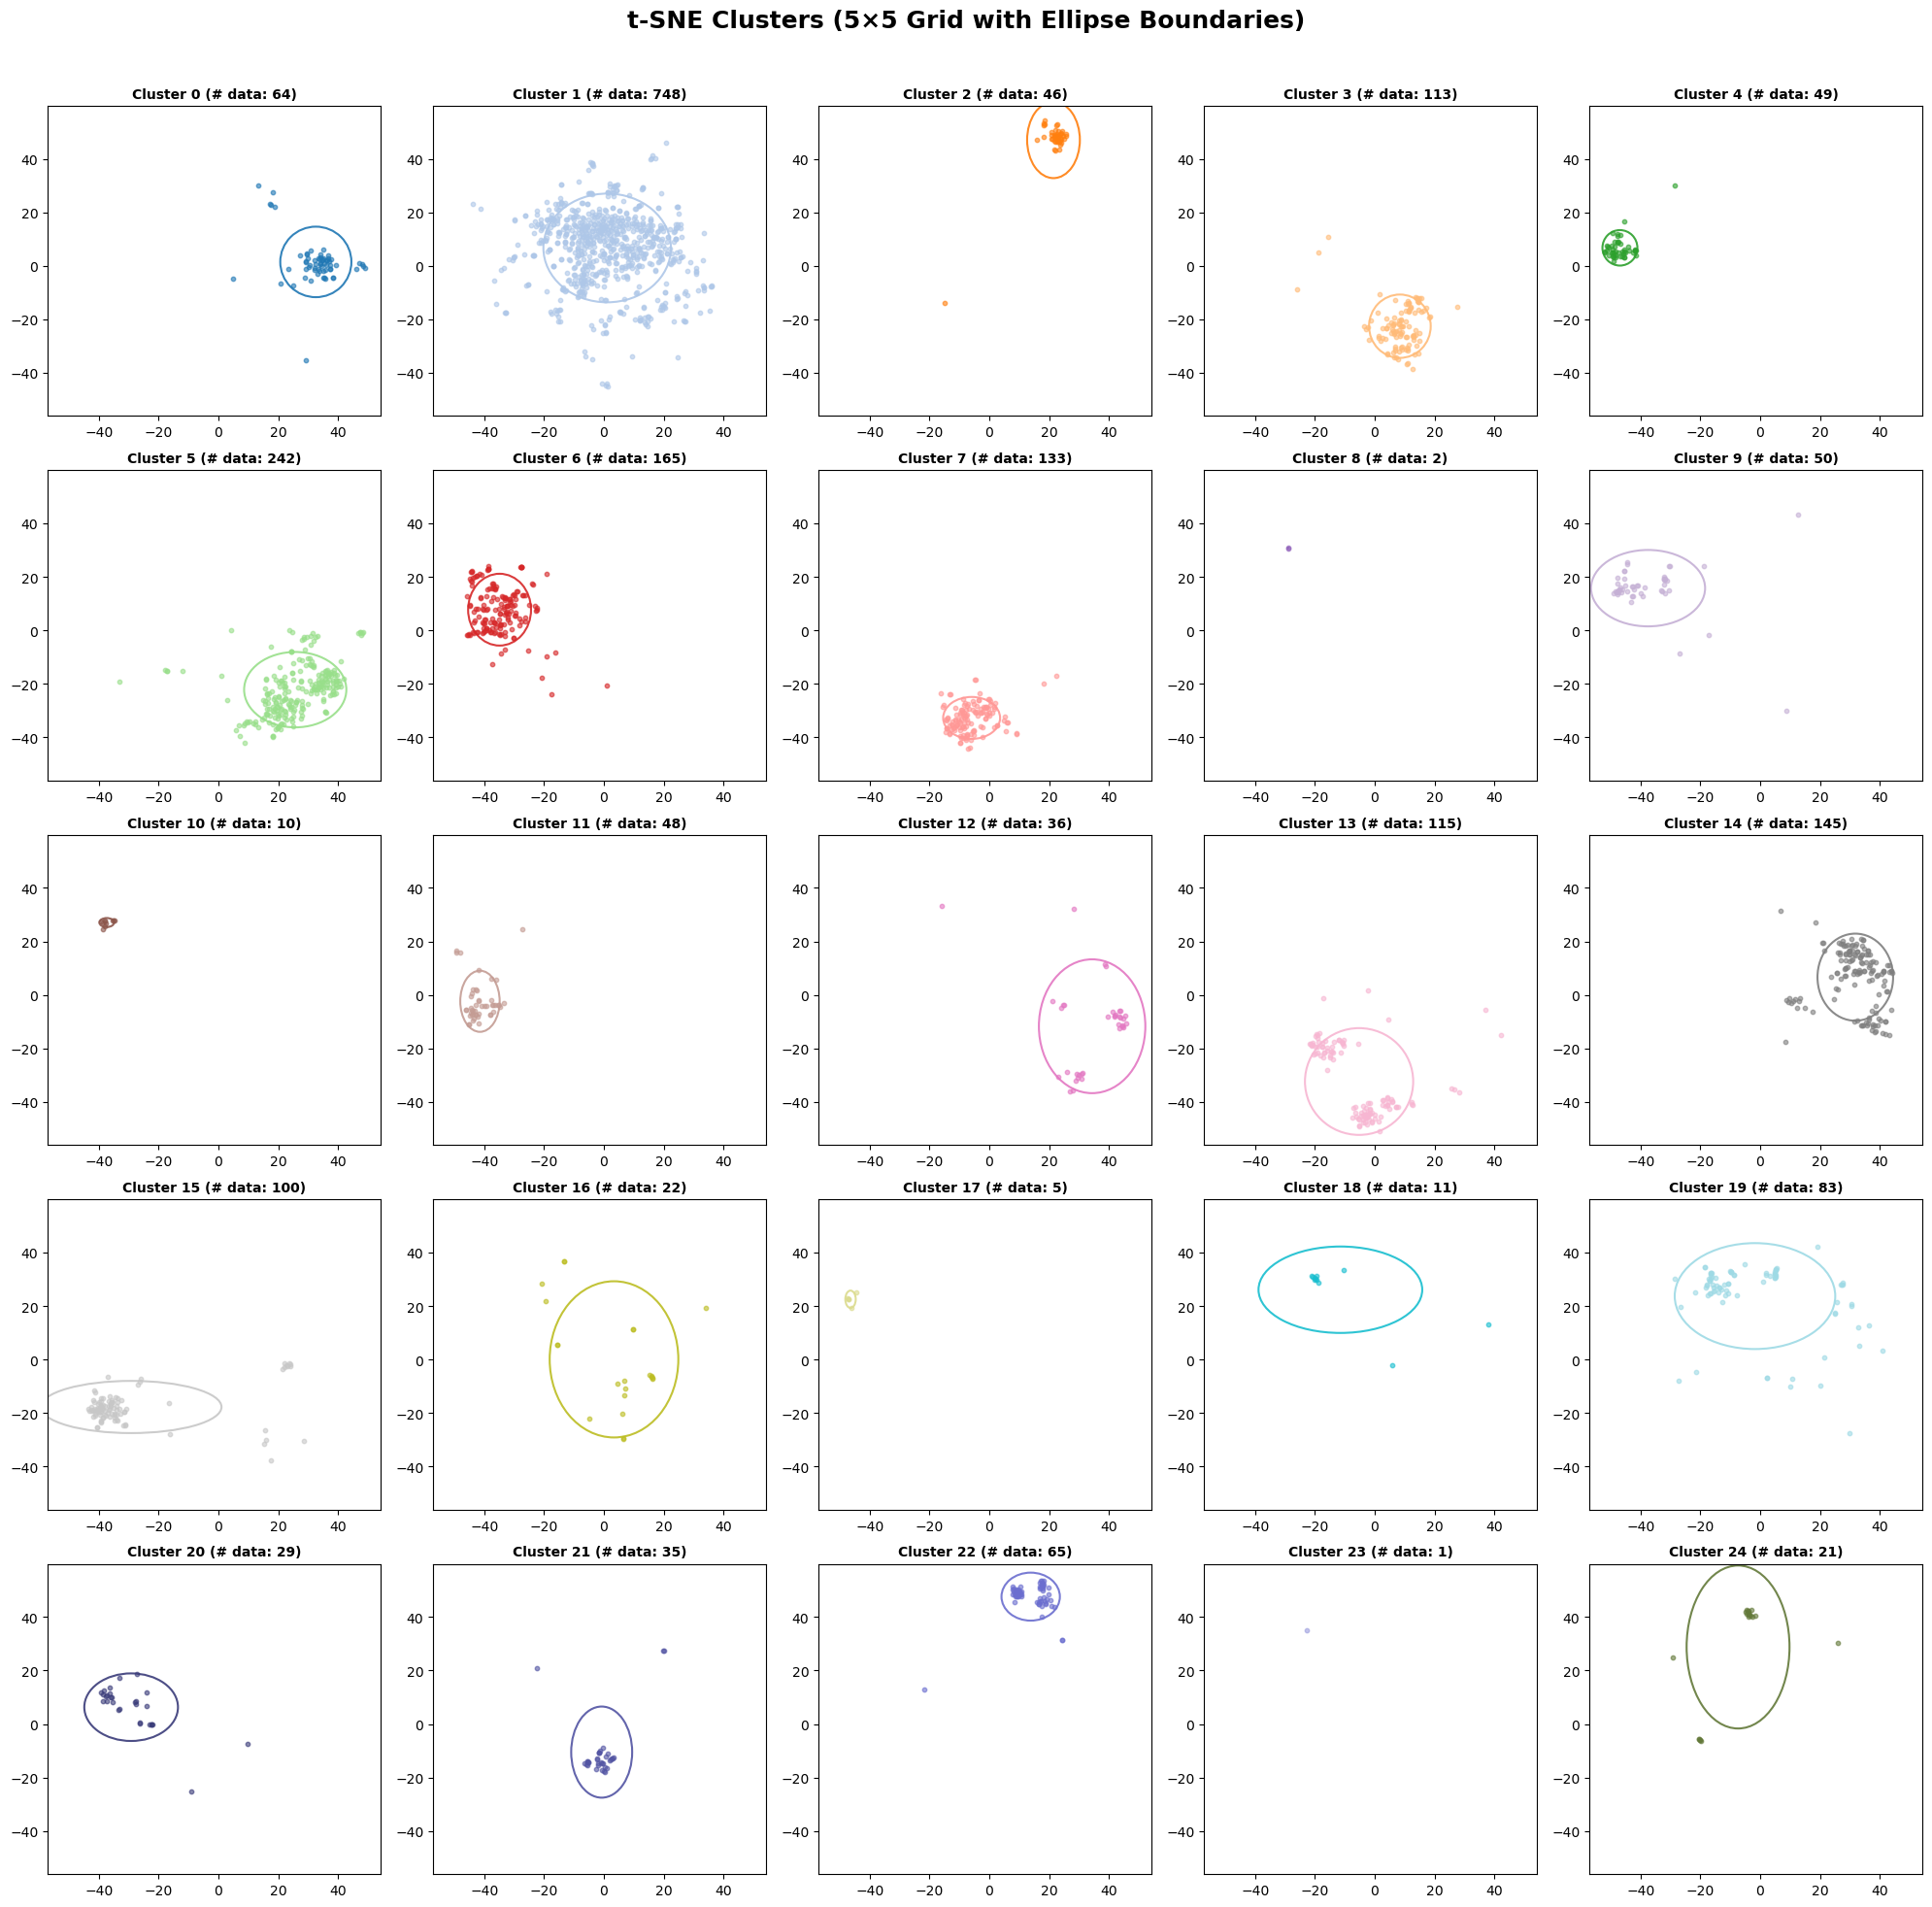

In [40]:
import matplotlib.patches as mpatches
from scipy.spatial import ConvexHull

# Helper function: scalable distinct color palette
def get_cluster_colors(n_clusters):
    """
    Return a list of colors that can handle up to ~60 distinct clusters
    using a combination of tab20, tab20b, and tab20c colormaps.
    """
    colors = np.vstack((
        plt.cm.tab20(np.linspace(0, 1, 20)),
        plt.cm.tab20b(np.linspace(0, 1, 20)),
        plt.cm.tab20c(np.linspace(0, 1, 20))
    ))
    if n_clusters > len(colors):
        # fallback to continuous color map if more than ~60 clusters
        colors = plt.cm.nipy_spectral(np.linspace(0, 1, n_clusters))
    else:
        colors = colors[:n_clusters]
    return colors

# -------------------------------------------------------------
# Visualization parameters
# -------------------------------------------------------------
n_clusters = optimal_k         # e.g. 25
boundary_type = "ellipse"      # "ellipse", "kde", or "hull"
colors = get_cluster_colors(n_clusters)

# Compute axis limits (same for all subplots within the option)
x_min, x_max = viz_df['x'].min(), viz_df['x'].max()
y_min, y_max = viz_df['y'].min(), viz_df['y'].max()

# Optionally tighten the range slightly (for nicer layout)
x_padding = (x_max - x_min) * 0.05
y_padding = (y_max - y_min) * 0.05
x_min, x_max = x_min - x_padding, x_max + x_padding
y_min, y_max = y_min - y_padding, y_max + y_padding

# Create 5×5 subplots (works best for 25 clusters)
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.flatten()

for cluster_id in range(n_clusters):
    ax = axes[cluster_id]
    cluster_data = viz_df[viz_df['cluster'] == cluster_id]

    # Plot cluster points
    ax.scatter(cluster_data['x'], cluster_data['y'],
               c=[colors[cluster_id]], alpha=0.6, s=10)

    # OPTION 1 — Elliptical Boundary
    if boundary_type == "ellipse" and len(cluster_data) > 1:
        x_mean, y_mean = cluster_data['x'].mean(), cluster_data['y'].mean()
        x_std, y_std = cluster_data['x'].std(), cluster_data['y'].std()

        ellipse = mpatches.Ellipse(
            (x_mean, y_mean),
            width=3 * x_std,
            height=3 * y_std,
            fill=False,
            edgecolor=colors[cluster_id],
            linewidth=1.5,
            alpha=0.9
        )
        ax.add_patch(ellipse)

    # OPTION 2 — KDE Contour Boundary
    elif boundary_type == "kde" and len(cluster_data) > 5:
        sns.kdeplot(
            x=cluster_data['x'],
            y=cluster_data['y'],
            ax=ax,
            levels=1,
            color=colors[cluster_id],
            linewidths=1.2,
            alpha=0.8
        )

    # OPTION 3 — Convex Hull Boundary
    elif boundary_type == "hull" and len(cluster_data) >= 3:
        points = cluster_data[['x', 'y']].values
        hull = ConvexHull(points)
        for simplex in hull.simplices:
            ax.plot(points[simplex, 0], points[simplex, 1],
                    color=colors[cluster_id], alpha=0.8, linewidth=1.2)

    # Style each subplot
    ax.set_title(f'Cluster {cluster_id} (# data: {len(cluster_data)})', fontsize=10, fontweight='bold')
    # ax.set_xticks([])
    # ax.set_yticks([])
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(False)

# # Hide unused subplots if fewer than 25 clusters
# for i in range(n_clusters, 25):
#     fig.delaxes(axes[i])

fig.suptitle(f't-SNE Clusters (5×5 Grid with {boundary_type.capitalize()} Boundaries)',
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()


In [48]:
list(viz_df[viz_df['cluster'] == 0]["subreddit"]) # related to country

['europe',
 'canada',
 'australia',
 'syriancivilwar',
 'unitedkingdom',
 'formula1',
 'brasil',
 'ukpolitics',
 'de',
 'france',
 'romania',
 'islam',
 'toronto',
 'ireland',
 'italy',
 'aviation',
 'newzealand',
 'vancouver',
 'russia',
 'boxing',
 'london',
 'israel',
 'portugal',
 'canadapolitics',
 'mexico',
 'denmark',
 'tennis',
 'china',
 'militaryporn',
 'turkey',
 'mapporn',
 'ukrainianconflict',
 'scotland',
 'suomi',
 'croatia',
 'thenetherlands',
 'pakistan',
 'greece',
 'korea',
 'quebec',
 'labouruk',
 'shitamericanssay',
 'malaysia',
 'germany',
 'warshipporn',
 'geopolitics',
 'arabs',
 'vzla',
 'machinelearning',
 'indonesia',
 'combatfootage',
 'iran',
 'polska',
 'hongkong',
 'northernireland',
 'belgium',
 'austria',
 'serbia',
 'africa',
 'kurdistan',
 'ukraine',
 'armenia',
 'syriancirclejerkwar',
 'iranian']